# Qwen+GRPO后训练复杂医疗问题推理和疾病诊断

In [1]:
import os
os.environ['UNSLOTH_USE_MODELSCOPE'] = '1'      # 使用modelscope下载模型和数据
os.environ['UNSLOTH_DISABLE_STATISTICS'] = '1'  # 禁用 Unsloth 在微调过程中自动收集统计信息
os.environ['OMP_NUM_THREADS'] = '4'             # OpenMP的并行线程设置

In [2]:
# 1.速度快，显存占用更少
# 2.openai triton重写了gpu的kernel，比cuda实现更高效
# 3.与transformers, trl, peft兼容的

In [3]:
# 打印关键库版本
from importlib.metadata import version
print("pytorch version: ", version('torch'))
print("Transformers version: ", version('Transformers'))
print("unsloth version: ", version('unsloth'))
print("unsloth_zoo version: ", version('unsloth_zoo'))
print("trl: ", version('trl'))
print("xformers: ", version('xformers'))
print("Datasets: ", version('Datasets'))
print("Tokenizers: ", version('Tokenizers'))

pytorch version:  2.8.0
Transformers version:  4.57.3
unsloth version:  2025.12.10
unsloth_zoo version:  2025.12.8
trl:  0.24.0
xformers:  0.0.32.post1
Datasets:  4.3.0
Tokenizers:  0.22.2


In [4]:
# 引入unsloth以及GRPO最新的patch
from unsloth import FastLanguageModel, PatchFastRL
PatchFastRL("GRPO", FastLanguageModel)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
INFO 02-23 18:36:11 [__init__.py:216] Automatically detected platform cuda.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: UnslothBCOTrainer is already patched.
Unsloth: UnslothCPOTrainer is already patched.
Unsloth: UnslothDPOTrainer is already patched.
Unsloth: UnslothGKDTrainer is already patched.
Unsloth: UnslothGRPOTrainer is already patched.
Unsloth: UnslothKTOTrainer is already patched.
Unsloth: UnslothNashMDTrainer is already patched.
Unsloth: UnslothOnlineDPOTrainer is already patched.
Unsloth: UnslothORPOTrainer is already patched.
Unsloth: UnslothPPOTrainer is already patched.
Unsloth: UnslothPRMTrainer is already patched.
Unsloth: UnslothRewardTrainer is already patched.
Unsloth: UnslothRLOOTrainer is already patched.
Unsloth: UnslothSFTTrainer is already patched.
Unsloth: UnslothXPOTrainer is already patched.


## 加载模型

In [5]:
import torch
max_prompt_len = 512  # 输入最大长度
max_output_len = 512  # 输出最大长度，如果要实现long-cot,可以增大，但是显存也会占用更多
max_seq_length = max_prompt_len +  max_output_len # 512 input + 512 output
lora_rank = 64  # rank越大效果越好，不过速度更慢，显存要求更多

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "Qwen/Qwen2.5-3B-Instruct", # 选择没有思考的模式的模型
    max_seq_length = max_seq_length,
    load_in_4bit = True, # 基座用4bit量化加载（动态4bit量化）
    fast_inference = True, # 使用vLLM加快推理，base(vllm)+adapter(unsloth bf16)
    max_lora_rank = lora_rank,
    gpu_memory_utilization = 0.5, # 如果OOM了，就减少该比例
)

model = FastLanguageModel.get_peft_model(
    model,
    r = lora_rank,
    target_modules = [
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ], # 可以根据显存情况去选择微调的参数，例如显存有限且发生OOM了，可以把qkvo4个proj删掉，只微调ffn的linear层
    lora_alpha = lora_rank,
    use_gradient_checkpointing = "unsloth", # unsloth专门做过显存优化，相比transformers库显存降低30%，而且可以实现自动卸载avtivation到cpu
    random_state = 3407,     #随机种子
)

2026-02-23 18:44:20,685 - modelscope - INFO - Target directory already exists, skipping creation.


INFO 02-23 18:44:20 [vllm_utils.py:702] Unsloth: Patching vLLM v1 graph capture
INFO 02-23 18:44:20 [vllm_utils.py:732] Unsloth: Patching vLLM v0 graph capture
==((====))==  Unsloth 2025.12.10: Fast Qwen2 patching. Transformers: 4.57.3. vLLM: 0.10.2.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.527 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.8.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.4.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.32.post1. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: vLLM loading /root/.cache/modelscope/hub/models/unsloth/qwen2___5-3b-instruct-unsloth-bnb-4bit with actual GPU utilization = 49.1%
Unsloth: Your GPU has CUDA compute capability 8.9 with VRAM = 23.53 GB.
Unsloth: Using conservativeness = 1.0. Chunked prefill tokens = 1024. Num Sequences = 48.
Unsloth: vLLM's KV Cache can use up to 9.13 GB. Also

`torch_dtype` is deprecated! Use `dtype` instead!


INFO 02-23 18:44:29 [__init__.py:1815] Using max model len 1024
WARNING 02-23 18:44:29 [_ipex_ops.py:16] Import error msg: No module named 'intel_extension_for_pytorch'
INFO 02-23 18:44:31 [scheduler.py:222] Chunked prefill is enabled with max_num_batched_tokens=4096.
WARNING 02-23 18:44:31 [lora.py:92] `lora_extra_vocab_size` is deprecated and will be removed in v0.12.0. Additional vocabulary support for LoRA adapters is being phased out.
Unsloth: vLLM Bitsandbytes config using kwargs = {'load_in_8bit': False, 'load_in_4bit': True, 'bnb_4bit_compute_dtype': 'bfloat16', 'bnb_4bit_quant_storage': 'uint8', 'bnb_4bit_quant_type': 'nf4', 'bnb_4bit_use_double_quant': True, 'llm_int8_enable_fp32_cpu_offload': False, 'llm_int8_has_fp16_weight': False, 'llm_int8_skip_modules': ['lm_head', 'multi_modal_projector', 'merger', 'modality_projection', 'model.layers.2.mlp', 'model.layers.3.mlp', 'model.layers.30.mlp'], 'llm_int8_threshold': 6.0}
INFO 02-23 18:44:31 [core.py:76] Initializing a V1 LLM 

[W223 18:44:32.223693206 ProcessGroupNCCL.cpp:981] Warning: TORCH_NCCL_AVOID_RECORD_STREAMS is the default now, this environment variable is thus deprecated. (function operator())


...

INFO 02-23 18:44:55 [gpu_model_runner.py:3118] Graph capturing finished in 5 secs, took 0.58 GiB
INFO 02-23 18:44:55 [vllm_utils.py:714] Unsloth: Patched vLLM v1 graph capture finished in 5 secs.


INFO 02-23 18:44:56 [gpu_worker.py:391] Free memory on device (23.04/23.53 GiB) on startup. Desired GPU memory utilization is (0.49102651575094236, 11.55 GiB). Actual usage is 2.44 GiB for weight, 0.4 GiB for peak activation, 0.02 GiB for non-torch memory, and 0.58 GiB for CUDAGraph memory. Replace gpu_memory_utilization config with `--kv-cache-memory=8561191936` to fit into requested memory, or `--kv-cache-memory=20900539392` to fully utilize gpu memory. Current kv cache memory in use is 9339235328 bytes.
INFO 02-23 18:44:56 [core.py:218] init engine (profile, create kv cache, warmup model) took 21.64 seconds
INFO 02-23 18:44:57 [llm.py:295] Supported_tasks: ('generate',)
INFO 02-23 18:44:57 [__init__.py:36] No IOProcessor plugins requested by the model
Unsloth: Just some info: will skip parsing ['layer_norm2', 'post_attention_layernorm', 'attention_norm', 'layer_norm1', 'norm1', 'q_norm', 'post_feedforward_layernorm', 'pre_feedforward_layernorm', 'ffn_norm', 'input_layernorm', 'norm2

Some weights of Qwen2ForCausalLM were not initialized from the model checkpoint at /root/.cache/modelscope/hub/models/unsloth/qwen2___5-3b-instruct-unsloth-bnb-4bit and are newly initialized: ['lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Performing substitution for additional_keys=set()
Unsloth: Just some info: will skip parsing ['layer_norm2', 'post_attention_layernorm', 'attention_norm', 'layer_norm1', 'norm1', 'cross_attn_post_attention_layernorm', 'q_norm', 'post_feedforward_layernorm', 'pre_feedforward_layernorm', 'ffn_norm', 'input_layernorm', 'norm2', 'post_layernorm', 'norm', 'cross_attn_input_layernorm', 'k_norm']


Unsloth 2025.12.10 patched 36 layers with 36 QKV layers, 36 O layers and 36 MLP layers.


## 准备数据

In [6]:
from datasets import load_dataset, Dataset
from sklearn.model_selection import train_test_split

SYSTEM_PROMPT = """
Respond in the following format:
<reasoning>
...
</reasoning>
<answer>
...
</answer>
"""

def get_medical_questions(data_path):
    # 从本地加载json文件
    data = load_dataset("json", data_files=data_path)["train"]
    # 转换成dataframe
    df = data.to_pandas()

    # 99%的数据做训练，1%的数据做测试，大约200条
    train_df, test_df = train_test_split(df, test_size=0.01, random_state=42)

    # 转换回huggingface datasets
    train_dataset = Dataset.from_pandas(train_df)
    test_dataset = Dataset.from_pandas(test_df)

    # 构建chat-ml所需要的对话数据格式
    def map_fn(x):
        return {
            'prompt': [
                {'role': 'system', 'content': SYSTEM_PROMPT},
                {'role': 'user', 'content': x['Question']}
            ],
            'answer': x['Response'],  # 参考答案
            'question': x['Question']
        }

    # 处理数据格式，并移除不需要的列
    train_dataset = train_dataset.map(map_fn).remove_columns(['Question', 'Complex_CoT', 'Response', '__index_level_0__'])
    test_dataset = test_dataset.map(map_fn).remove_columns(['Question', 'Complex_CoT', 'Response', '__index_level_0__'])

    return train_dataset, test_dataset

data_path = 'data/FreedomIntelligence/medical-o1-reasoning-SFT/medical_o1_sft.json'
train_dataset, test_dataset = get_medical_questions(data_path)
train_dataset, test_dataset

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

(Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 19506
 }),
 Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 198
 }))

In [7]:
# 根据长度过滤数据
train_dataset = train_dataset.map(lambda x: {"input_len": len(tokenizer.apply_chat_template(x["prompt"]))})
train_dataset = train_dataset.map(lambda x: {"output_len": len(tokenizer(x["answer"])["input_ids"])})
test_dataset = test_dataset.map(lambda x: {"input_len": len(tokenizer.apply_chat_template(x["prompt"]))})
test_dataset = test_dataset.map(lambda x: {"output_len": len(tokenizer(x["answer"])["input_ids"])})
train_dataset = train_dataset.filter(lambda x: x["input_len"] <= max_prompt_len and x["output_len"] <= max_output_len)
test_dataset = test_dataset.filter(lambda x: x["input_len"] <= max_prompt_len and x["output_len"] <= max_output_len)
train_dataset = train_dataset.remove_columns(['input_len', "output_len"])
test_dataset = test_dataset.remove_columns(['input_len', "output_len"])
train_dataset, test_dataset

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/19506 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Map:   0%|          | 0/198 [00:00<?, ? examples/s]

Filter:   0%|          | 0/19506 [00:00<?, ? examples/s]

Filter:   0%|          | 0/198 [00:00<?, ? examples/s]

(Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 19481
 }),
 Dataset({
     features: ['prompt', 'answer', 'question'],
     num_rows: 198
 }))

### Reward 函数设计
Reward = 0.5 * SemanticCorrectness + 0.4 * PerplexityScore + 0.1 * TagPresence

1.SemanticCorrectness用一个cross-encoder model (`cross-encoder/stsb-roberta-base`)计算和标准答案的语义正确性得分

2.PerplexityScore采用**BioGPT** (`microsoft/biogpt`)计算医学语言流畅性得分和语言质量

3.TagPresence检查输出的答案是否符合先思考后答案的格式

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import CrossEncoder
from typing import List
import re

# ------ Device设置 ------
main_device = "cuda" if torch.cuda.is_available() else "cpu"
reward_device = "cuda" if torch.cuda.is_available() else "cpu"

# ------ 语义正确性得分 ------
semantic_model = CrossEncoder('pretrained/cross-encoder/stsb-roberta-base', device=reward_device)
def semantic_correctness(responses: List[str], answers: List[str]) -> List[float]:
    """Calculate semantic similarity using cross-encoder"""
    with torch.no_grad():            
        inputs = list(zip(responses, answers))
        similarities = semantic_model.predict(inputs, show_progress_bar=False).tolist()
        # 如果回答为空，则输出-1
        similarities = [-1.0 if response == "" else similarity for response, similarity in zip(responses, similarities)]
        return similarities

# ------ 流畅性得分 ------
class PerplexityCalculator:
    def __init__(self, model_name="pretrained/microsoft/biogpt", device=reward_device):
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.device = device
        self.tokenizer.pad_token = self.tokenizer.eos_token
        self.model = AutoModelForCausalLM.from_pretrained(model_name).to(self.device)
        self.model.eval()

    def calculate(self, texts: List[str], batch_size=8) -> List[float]:
        perplexities = []
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            try:
                if not batch: continue
                
                encodings = self.tokenizer(
                    batch, 
                    return_tensors="pt", 
                    padding=True, 
                    truncation=True,
                    max_length=200
                ).to(self.device)
                
                with torch.no_grad():
                    outputs = self.model(**encodings, labels=encodings.input_ids)
                
                loss = outputs.loss
                if torch.isnan(loss):
                    raise ValueError("NaN loss encountered")
                
                batch_perplexity = torch.exp(loss).repeat(len(batch)).cpu().tolist()
                # 如果回答为空，则输出-1
                batch_perplexity = [-1.0 if text == "" else perplex for text, perplex in zip(batch, batch_perplexity)]
                perplexities.extend(batch_perplexity)
                                
            except Exception as e:
                print(f"Error in batch {i//batch_size}: {str(e)}")
                perplexities.extend([1000.0] * len(batch))
        
        return perplexities

perplexity_calculator = PerplexityCalculator()

# ------ 输出格式得分 ------
def tag_presence_reward(completions: List[dict]) -> List[float]:
    """Reward for presence of <reasoning> and <answer> tags"""
    rewards = []
    for completion in completions:
        content = completion[0]['content']
        has_reasoning = bool(re.search(r'<reasoning>.*?</reasoning>', content, re.DOTALL))
        has_answer = bool(re.search(r'<answer>.*?</answer>', content, re.DOTALL))
        reward = 0.5 * has_reasoning + 0.5 * has_answer
        rewards.append(reward)
    return rewards

# ------ 综合加权得分 ------
def combined_reward_func(
    prompts, completions, answer, **kwargs
) -> List[float]:
    # 抽取答案
    responses = []
    valid_indices = []
    full_outputs = []
    for idx, completion in enumerate(completions): # vllm输出的
        try:
            generated_content = completion[0]['content'].strip() # reasoning + answer
            full_outputs.append(generated_content)
            answer_match = re.search(r'<answer>(.*?)</answer>', generated_content, re.DOTALL)
            if answer_match:
                generated_content = answer_match.group(1).strip()
            else:
                responses.append("")  # 如果没有抽取出答案，则给空
                valid_indices.append(idx)
                continue
            
            # 处理边界条件：1.答案为空   2.答案复制输入
            user_prompt = prompts[idx][-1]['content']
            if not generated_content or generated_content == user_prompt:
                responses.append("")
                valid_indices.append(idx)
                continue
                
            responses.append(generated_content)
            valid_indices.append(idx)
        except (KeyError, IndexError):
            responses.append("")
            valid_indices.append(idx)
            continue
    
    if not responses:
        return [-1.0] * len(completions)
    
    # 计算rewards
    try:
        processed_answers = answer
        similarities = semantic_correctness(responses, [processed_answers[i] for i in valid_indices])
        perplexities = perplexity_calculator.calculate([full_outputs[i] for i in valid_indices])
        tag_rewards = tag_presence_reward([completions[i] for i in valid_indices])
    except Exception as e:
        print(f"Reward calculation error: {str(e)}")
        return [-1.0] * len(completions)
    
    # 转换成tensor
    sim_scores = torch.nan_to_num(torch.tensor(similarities), nan=0.0)
    perplex_scores = torch.nan_to_num(torch.tensor(perplexities), nan=1000.0)
    tag_scores = torch.tensor(tag_rewards)
        
    # 困惑度归一化
    perplex_rewards = 1 / (perplex_scores / (perplex_scores.mean() + 1e-9))
    score_range = perplex_rewards.max() - perplex_rewards.min()
    if score_range < 1e-6:
        perplex_rewards_normalized = torch.ones_like(perplex_rewards) * 0.5
    else:
        perplex_rewards_normalized = (perplex_rewards - perplex_rewards.min()) / score_range # min-max归一化[-1, 1]
    
    # 加权
    combined = [
        0.5 * sim.item() + 0.4 * pr.item() + 0.1 * tag.item()
        for sim, pr, tag in zip(sim_scores, perplex_rewards_normalized, tag_scores)
        if not torch.isnan(sim) and not torch.isnan(pr) and not torch.isnan(tag)
    ]
    
    # clip rewards，保证在-1~1之间
    final_rewards = [-1.0] * len(completions)
    for idx, reward in zip(valid_indices, combined):
        final_rewards[idx] = max(min(reward, 1.0), -1.0)  # Clamp between -1 and 1
    
    assert len(final_rewards) == len(completions), "Reward mapping error"

    return final_rewards

## GRPO的配置

In [7]:
from trl import GRPOConfig, GRPOTrainer
training_args = GRPOConfig(
    use_vllm=True,  # use vLLM for fast inference!
    learning_rate=5e-6,  # 学习率
    weight_decay=0.001,  # 权重衰减
    warmup_ratio=0.1,    # warmup ratio
    max_grad_norm=0.1,   # 最大梯度范数，防止更新过快
    per_device_train_batch_size=5,    # 如果OOM，可以设置小点，这个值一般是num_generations的倍数
    gradient_accumulation_steps=4,    # 梯度累积步数
    num_generations=5,  # rollout采样大小，如果太大，可以设置小点
    max_prompt_length=max_prompt_len,  # 输入长度
    max_completion_length=max_output_len, #输出长度
    max_steps=200,    # 训练最大步数
    save_steps=200,   # 保存模型最大间隔
    lr_scheduler_type="cosine",  # 学习率衰减
    optim="adamw_8bit",  # 优化器
    logging_steps=1,     # 日志打印间隔
    bf16=True,           # 是否启用bf16训练
    report_to="none",    
    output_dir="saved/", # checkpoint保存目录，这个只保存lora和optimizer参数
    save_strategy="steps" #保存的策略（按step还是epoch）
)

## 开始训练

In [8]:
trainer = GRPOTrainer(
    model = model,
    processing_class = tokenizer,
    reward_funcs = [
        combined_reward_func
    ],
    args = training_args,
    train_dataset = train_dataset,
)
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 19,481 | Num Epochs = 1 | Total steps = 200
O^O/ \_/ \    Batch size per device = 5 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (5 x 4 x 1) = 20
 "-____-"     Trainable parameters = 119,734,272 of 3,205,672,960 (3.74% trained)


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,reward,reward_std,completions / mean_length,completions / min_length,completions / max_length,completions / clipped_ratio,completions / mean_terminated_length,completions / min_terminated_length,completions / max_terminated_length,sampling / sampling_logp_difference / mean,sampling / sampling_logp_difference / max,sampling / importance_sampling_ratio / min,sampling / importance_sampling_ratio / mean,sampling / importance_sampling_ratio / max,kl,rewards / combined_reward_func / mean,rewards / combined_reward_func / std
1,-0.000200,-0.297521,0.244954,364.000000,260.000000,504.000000,0.000000,364.000000,260.000000,504.000000,0,0,0,0,0,0.001093,-0.297521,0.291033
2,-0.000300,-0.067512,0.201302,362.500000,231.000000,512.000000,0.100000,345.888885,231.000000,495.000000,No Log,No Log,No Log,No Log,No Log,0.001327,-0.067512,0.428531
3,-0.000500,0.098891,0.366045,336.950012,195.000000,512.000000,0.050000,327.736847,195.000000,492.000000,No Log,No Log,No Log,No Log,No Log,0.001475,0.098891,0.409177
4,-0.000400,-0.163796,0.171085,348.700012,198.000000,512.000000,0.200000,307.875000,198.000000,415.000000,No Log,No Log,No Log,No Log,No Log,0.002563,-0.163796,0.357310
5,0.000900,0.071456,0.252674,360.450012,165.000000,512.000000,0.100000,343.611115,165.000000,480.000000,No Log,No Log,No Log,No Log,No Log,0.001178,0.071456,0.339138
6,0.000600,-0.037469,0.177705,380.300018,183.000000,512.000000,0.200000,347.375000,183.000000,435.000000,No Log,No Log,No Log,No Log,No Log,0.001641,-0.037469,0.533613
7,0.000200,-0.294669,0.156592,333.750000,204.000000,471.000000,0.000000,333.750000,204.000000,471.000000,No Log,No Log,No Log,No Log,No Log,0.001551,-0.294669,0.245478
8,-0.000300,-0.064698,0.206762,305.850006,168.000000,512.000000,0.100000,282.944458,168.000000,402.000000,No Log,No Log,No Log,No Log,No Log,0.005998,-0.064698,0.269599
9,0.000700,0.036162,0.281339,299.149994,124.000000,475.000000,0.000000,299.149994,124.000000,475.000000,No Log,No Log,No Log,No Log,No Log,0.001876,0.036162,0.525536
10,0.000300,0.242222,0.274164,331.600006,167.000000,512.000000,0.050000,322.105255,167.000000,508.000000,No Log,No Log,No Log,No Log,No Log,0.001023,0.242222,0.483446


TrainOutput(global_step=200, training_loss=0.3011127418235992, metrics={'train_runtime': 2121.7009, 'train_samples_per_second': 1.885, 'train_steps_per_second': 0.094, 'total_flos': 0.0, 'train_loss': 0.3011127418235992})

## 打印训练日志

In [9]:
history = trainer.state.log_history
history[:3]

[{'loss': -0.0002,
  'grad_norm': 0.2479148805141449,
  'learning_rate': 0.0,
  'num_tokens': 9085.0,
  'completions/mean_length': 364.0,
  'completions/min_length': 260.0,
  'completions/max_length': 504.0,
  'completions/clipped_ratio': 0.0,
  'completions/mean_terminated_length': 364.0,
  'completions/min_terminated_length': 260.0,
  'completions/max_terminated_length': 504.0,
  'rewards/combined_reward_func/mean': -0.2975209653377533,
  'rewards/combined_reward_func/std': 0.2910332679748535,
  'reward': -0.2975209653377533,
  'reward_std': 0.24495354294776917,
  'frac_reward_zero_std': 0.0,
  'completion_length': 364.00000762939453,
  'kl': 0.0010934675665339455,
  'epoch': 0.0002053388090349076,
  'step': 1},
 {'loss': -0.0003,
  'grad_norm': 0.23461125791072845,
  'learning_rate': 2.5000000000000004e-07,
  'num_tokens': 17995.0,
  'completions/mean_length': 362.5,
  'completions/min_length': 231.0,
  'completions/max_length': 512.0,
  'completions/clipped_ratio': 0.10000000149011

In [10]:
# 保存日志
import json
with open("saved/history_log.txt", "w") as fw:
    fw.write(json.dumps(history, ensure_ascii=False, indent=2))

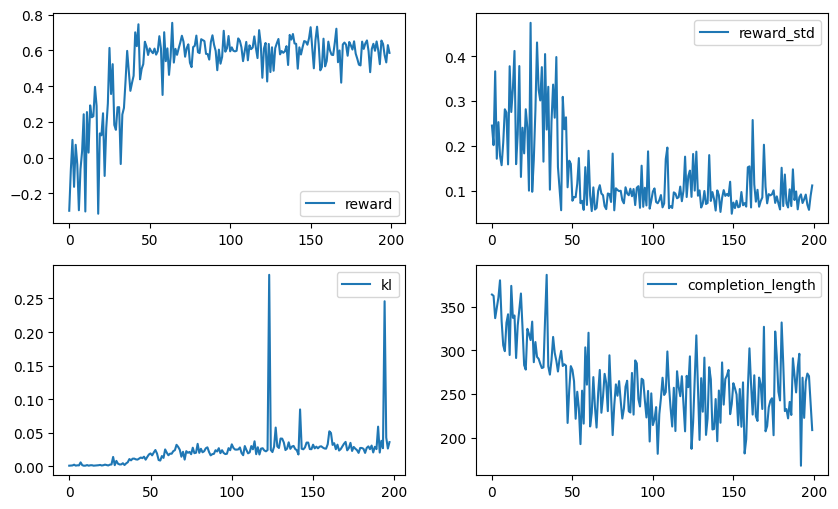

In [11]:
# 画图
import matplotlib.pyplot as plt

reward = [item["reward"] for item in history if "reward" in item]
reward_std = [item["reward_std"] for item in history if "reward_std" in item]
kl = [item["kl"] for item in history if "kl" in item and item["kl"] < 1.0]
completion_length = [item["completion_length"] for item in history if "completion_length" in item]

plt.figure(figsize=(10, 6))
plt.subplot(2, 2, 1)
plt.plot(reward, label="reward")
plt.legend()
plt.subplot(2, 2, 2)
plt.plot(reward_std, label="reward_std")
plt.legend()
plt.subplot(2, 2, 3)
plt.plot(kl, label="kl")
plt.legend()
plt.subplot(2, 2, 4)
plt.plot(completion_length, label="completion_length")
plt.legend()
plt.show()
    

In [12]:
# 保存lora
model.save_lora("saved/qwen_grpo_medical_reasoning_lora")

## 测试

In [8]:
from vllm import SamplingParams
sampling_params = SamplingParams(
    n = 1,
    temperature = 0.8,
    top_p = 0.95,
    max_tokens = 1024,
)

# GRPO训练前
text = tokenizer.apply_chat_template(test_dataset[0]["prompt"], tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    [text],
    sampling_params = sampling_params,
    lora_request = None,
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
The woman's symptoms suggest an inflammatory bowel disease (IBD) such as Crohn's disease or ulcerative colitis. Given the information, it appears she has NOD2 dysfunction. The NOD2 protein, also known as CARD15, is a member of the Nod-like receptor family, which plays a crucial role in recognizing bacterial products, particularly those from Mycobacterium tuberculosis and other pathogens. When dysfunctional, it can lead to chronic inflammation in the gastrointestinal tract, resulting in symptoms of IBD.

The perianal fistula and diarrhea are consistent with the findings of Crohn's disease, which is characterized by inflammation affecting the digestive tract from the mouth to the anus, including the terminal ileum. However, the diagnosis can be confirmed through endoscopic examination and histopathological analysis, including identification of NOD2 dysfunction.

The protein most likely overactive due to this dysfunction is NOD2 (CARD15). Dysfunction in this protein can lead t

In [9]:
# GRPO训练后
text = tokenizer.apply_chat_template(test_dataset[0]["prompt"], tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
Given the clinical presentation and the immunohistochemistry finding of dysfunction in the NOD2 protein, we need to understand the function of NOD2 and its role in the immune system. NOD2 is a member of the Nod-like receptor family, which plays a role in innate immunity by recognizing specific molecules from bacteria and fungi. The dysfunction in NOD2 can lead to an overactive immune response against these molecules, which can manifest as symptoms like those described.
</reasoning>
<answer>
The immunological protein that is most likely overactive due to this dysfunction is NOD2. Dysfunction in NOD2 can lead to an overactive immune response, which can manifest in symptoms such as severe crampy abdominal pain, nonbloody diarrhea, mild abdominal distension, and a perianal fistula draining stool.
</answer>


In [10]:
# 测试中文输入
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '针对一名30岁患有慢性肾炎6年的男性患者，他的血液化验结果为BUN 118mmol/L，SCr 285μmol/L，血红蛋白80g/L，尿蛋白100mg/dl，根据这些指标，最合适的治疗方案是什么？',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
该患者的血肌酐（SCr）水平（285μmol/L）和尿蛋白（100mg/dl）水平明显升高，表明患者可能存在肾功能不全。BUN（血尿素氮）水平（118mmol/L）也偏高，提示氮质代谢产物的排泄不畅，进一步证实了慢性肾炎的存在。血红蛋白水平（80g/L）低于正常值，表示患者有贫血的表现。贫血在慢性肾炎患者中较为常见，可能与慢性肾脏疾病导致的铁代谢异常、维生素B12和叶酸吸收利用障碍等有关。
</reasoning>
<answer>
根据患者的具体情况，最合适的治疗方案应包括以下几点：
1. **饮食控制**：采用低蛋白、低盐、低磷饮食，以减轻肾脏负担。 
2. **药物治疗**：使用ACE抑制剂或ARBs药物控制血压，减少蛋白尿，保护肾功能；同时可能需要使用铁剂和维生素B12补充剂以治疗贫血；还需使用降脂药物控制血脂异常，以及使用抗凝药物预防心血管并发症。
3. **定期复查**：定期监测血肌酐、尿素氮、电解质、肾功能等指标，以及血红蛋白水平，以及尿蛋白定量，以便及时调整治疗方案。
4. **生活方式的调整**：建议患者减少体力劳动，避免劳累，保持良好生活习惯，如戒烟限酒等。
5. **肾替代治疗**：当肾功能严重受损，达到终末期肾病阶段时，可能需要考虑透析或肾移植等治疗措施。
</answer>


In [11]:
# 测试糖尿病酮症酸中毒 (DKA)
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '''背景: 24岁女性，王XX，因“恶心、呕吐、意识模糊1天”被送入急诊。关键病史: 1型糖尿病史10年，使用胰岛素泵治疗。3天前有感冒症状，食欲差，自行减少了胰岛素用量。
核心体征与化验: 体征: 生命体征: P 125次/分, R 30次/分 (深大呼吸), BP 95/60 mmHg。神志嗜睡，皮肤干燥，呼吸有烂苹果味。
急诊化验: 血糖: 28.5 mmol/L, 动脉血气 (ABG): pH 7.15, PaCO₂ 22 mmHg, HCO₃⁻ 8 mmol/L, 尿常规: 尿酮 +++, 尿糖 ++++, 血钾: 3.2 mmol/L. 
问题1: 该患者最可能的诊断是什么？ 
问题2: 诊断的核心依据是什么？（请列出三联征） 
问题3: 治疗该患者时，最优先、最紧急的初始治疗步骤是什么？
A. 立即静脉推注胰岛素 
B. 立即大量静脉补液 
C. 立即静脉滴注碳酸氢钠纠正酸中毒 
D. 立即静脉补钾 
问题4: 针对该患者当前的血钾水平（3.2 mmol/L），在开始胰岛素治疗时，需要遵循什么关键原则？ 
问题5: 除了诊断出的急症，该患者白细胞计数可能出现什么变化？为什么？''',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
问题1：根据病史和体征，该患者可能是糖尿病酮症酸中毒（DKA）。糖尿病酮症酸中毒是2型糖尿病的常见急性并发症，而1型糖尿病患者同样可能因为治疗不当发生DKA。
问题2：糖尿病酮症酸中毒的核心诊断依据为“三联征”：代谢性酸中毒、酮症和脱水。代谢性酸中毒表现为动脉血气分析中pH值降低，酮症则通过尿酮体检测证实，脱水则通过电解质分析和血容量评估来判断。
问题3：患者处于严重脱水状态，伴有代谢性酸中毒，血糖极高，最优先的治疗应是静脉补液，以纠正脱水和酸中毒，同时开始胰岛素治疗控制血糖。因此答案是B. 立即大量静脉补液。
问题4：患者目前血钾水平较低，且已经发生酸中毒，此时使用胰岛素时，为了防止进一步的低钾血症，需在初始治疗时给予补钾。但鉴于患者存在酸中毒，补钾时需要谨慎，避免加重酸中毒。所以最优先考虑的是在治疗初期进行补钾，但需要监测血钾水平，调整补钾速度。
问题5：白细胞计数可能出现异常。糖尿病酮症酸中毒患者可能因脱水、酸中毒等因素导致白细胞计数升高。此外，酸中毒和酮症可刺激白细胞产生，可能引起白细胞反应性增多。
</reasoning>

<answer>
问题1：糖尿病酮症酸中毒（DKA）
问题2：三联征包括代谢性酸中毒、酮症和脱水
问题3：B. 立即大量静脉补液
问题4：在治疗初期进行补钾，但需监测血钾水平
问题5：可能升高，因为酸中毒和酮症可刺激白细胞产生，导致白细胞反应性增多
</answer>


In [26]:
# 测试细菌性脑膜炎
custom_input = [
  {
      'content': '\nRespond in the following format:\n<reasoning>\n...\n</reasoning>\n<answer>\n...\n</answer>\n',
      'role': 'system'
  },
  {
      'content': '''背景:19岁男性，大学生，因“高热、剧烈头痛伴呕吐12小时”就诊急诊。关键病史:症状发展迅速，数小时内出现全脑炸裂样头痛，伴畏光、精神萎靡。既往健康，无外伤史。
核心体征与化验:体征:生命体征: T 39.8°C, P 115次/分, BP 110/70 mmHg。神志嗜睡，定向力差。
皮肤可见散在瘀点、瘀斑。颈部抵抗明显 (颈强直)，克氏征(+)。辅助检查:头颅CT平扫: 未见异常。
腰椎穿刺脑脊液 (CSF) 检查:外观: 脓性、浑浊压力: 310 mmH₂O (增高)白细胞: 2500 x 10⁶/L (显著增高)分类: 中性粒细胞 95%糖: 1.2 mmol/L (同步指尖血糖 8.0 mmol/L)蛋白: 2.5 g/L (显著增高)
问题1: 该患者最可能的诊断是什么？
问题2: 诊断的最关键实验室检查是哪一项？请解读其支持诊断的四个典型改变。
问题3: 根据患者的年龄和皮肤表现（瘀点、瘀斑），最可能的可疑病原体是哪一种？
问题4: 对于这类危重患者，在临床高度怀疑诊断但正在等待脑脊液结果时，最关键的治疗决策是什么？''',
      'role': 'user'
  }
]
text = tokenizer.apply_chat_template(custom_input, tokenize = False, add_generation_prompt = True)

output = model.fast_generate(
    text,
    sampling_params = sampling_params,
    lora_request = model.load_lora("saved/qwen_grpo_medical_reasoning_lora"),
)[0].outputs[0].text

print(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

<reasoning>
问题1：根据患者的症状（高热、剧烈头痛伴呕吐）、体征（全脑炸裂样头痛、畏光、精神萎靡、颈强直、克氏征阳性、脑脊液异常）以及既往史（无外伤史），最可能的诊断是脑膜炎，尤其是细菌性脑膜炎。
问题2：诊断的关键实验室检查是腰椎穿刺脑脊液检查。其支持诊断的典型改变包括：白细胞显著增高（中性粒细胞95%）、蛋白显著增高、糖降低、压力增高。
问题3：患者年龄较小，且有皮肤瘀点、瘀斑，这些体征提示可能为败血症或感染性休克，最可能的可疑病原体是革兰阴性杆菌，如大肠杆菌、克雷伯菌属等。
问题4：在等待脑脊液结果时，最关键的治疗决策是给予经验性抗生素治疗，如头孢曲松或美罗培南，同时给予支持治疗，包括液体复苏、电解质平衡、血糖控制等。
</reasoning>

<answer>
问题1：该患者最可能的诊断是细菌性脑膜炎。
问题2：诊断的关键实验室检查是腰椎穿刺脑脊液检查。其支持诊断的典型改变包括：白细胞显著增高（中性粒细胞95%）、蛋白显著增高、糖降低、压力增高。
问题3：根据患者的年龄和皮肤表现（瘀点、瘀斑），最可能的可疑病原体是革兰阴性杆菌，如大肠杆菌、克雷伯菌属等。
问题4：在临床高度怀疑诊断但正在等待脑脊液结果时，最关键的治疗决策是给予经验性抗生素治疗，如头孢曲松或美罗培南，同时给予支持治疗，包括液体复苏、电解质平衡、血糖控制等。
</answer>


## 评估在测试集上的表现

In [18]:
sampling_params = SamplingParams(
    n=1,
    temperature = 0.01,    # 低温降低随机性
    top_p = 0.95,
    max_tokens = 1024
)
# 预测GRPO训练前的结果
completions_not_tune = []
for idx in range(len(test_dataset)):
    text = tokenizer.apply_chat_template(test_dataset[idx]["prompt"], tokenize = False, add_generation_prompt = True)
    output = model.fast_generate(
        text,
        sampling_params = sampling_params
    )[0].outputs[0].text
    completions_not_tune.append(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [19]:
# 预测GRPO后训练的结果
completions = []
for idx in range(len(test_dataset)):
    text = tokenizer.apply_chat_template(test_dataset[idx]["prompt"], tokenize = False, add_generation_prompt = True)
    output = model.fast_generate(
        text,
        sampling_params = sampling_params,
        lora_request = model.load_lora("saved/qwen_grpo_medical_reasoning_lora"),
    )[0].outputs[0].text
    completions.append(output)

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

...

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

Adding requests:   0%|          | 0/1 [00:00<?, ?it/s]

Processed prompts:   0%|          | 0/1 [00:00<?, ?it/s, est. speed input: 0.00 toks/s, output: 0.00 toks/s]

In [20]:
# 把上面的comebined_reward_func copy下来改一下，同时返回各个子的reward和加权后reward，用于结果分析
from transformers import AutoModelForCausalLM, AutoTokenizer
from sentence_transformers import CrossEncoder
from typing import List
import re

# ------ 输出格式得分 ------
def tag_presence_reward(completions: List[dict]) -> List[float]:
    """Reward for presence of <reasoning> and <answer> tags"""
    rewards = []
    for content in completions:  # 处理一下输入
        has_reasoning = bool(re.search(r'<reasoning>.*?</reasoning>', content, re.DOTALL))
        has_answer = bool(re.search(r'<answer>.*?</answer>', content, re.DOTALL))
        reward = 0.5 * has_reasoning + 0.5 * has_answer
        rewards.append(reward)
    return rewards

# ------ 综合加权得分 ------
def combined_reward_func(
    prompts, completions, answer, **kwargs
) -> List[float]:
    # 抽取答案
    responses = []
    valid_indices = []
    for idx, generated_content in enumerate(completions):
        try:
            answer_match = re.search(r'<answer>(.*?)</answer>', generated_content, re.DOTALL)
            if answer_match:
                generated_content = answer_match.group(1).strip()
            elif "<answer>" in generated_content:    # 如果答案格式不对，取<answer>后面的内容作为结果
                generated_content = generated_content.split("<answer>")[1]
            else:
                responses.append("")  # 如果没有答案，则给空
                valid_indices.append(idx)
                continue
            
            # 处理边界条件：1.输出为空   2.输出复制输入
            user_prompt = prompts[idx][-1]['content']
            if not generated_content or generated_content == user_prompt:
                responses.append("")
                valid_indices.append(idx)
                continue
                
            responses.append(generated_content)
            valid_indices.append(idx)
        except (KeyError, IndexError):
            responses.append("")
            valid_indices.append(idx)
            continue
    
    if not responses:
        return [-1.0] * len(completions)
    
    # 计算rewards
    try:
        # 前两个reward score计算要用raw answer（不带输出格式的）
        processed_answers = answer
        similarities = semantic_correctness(responses, [processed_answers[i] for i in valid_indices])
        perplexities = perplexity_calculator.calculate([completions[i] for i in valid_indices])
        tag_rewards = tag_presence_reward([completions[i] for i in valid_indices])
    except Exception as e:
        print(f"Reward calculation error: {str(e)}")
        return [-1.0] * len(completions)
    
    # 转换成tensor
    sim_scores = torch.nan_to_num(torch.tensor(similarities), nan=0.0)
    perplex_scores = torch.nan_to_num(torch.tensor(perplexities), nan=1000.0)
    tag_scores = torch.tensor(tag_rewards)
        
    # 归一化后的困惑度
    perplex_rewards = 1 / (perplex_scores / (perplex_scores.mean() + 1e-9))
    score_range = perplex_rewards.max() - perplex_rewards.min()
    if score_range < 1e-6:
        perplex_rewards_normalized = torch.ones_like(perplex_rewards) * 0.5
    else:
        perplex_rewards_normalized = (perplex_rewards - perplex_rewards.min()) / score_range
    
    # 加权
    combined = [
        0.5 * sim.item() + 0.4 * pr.item() + 0.1 * tag.item()
        for sim, pr, tag in zip(sim_scores, perplex_rewards_normalized, tag_scores)
        if not torch.isnan(sim) and not torch.isnan(pr) and not torch.isnan(tag)
    ]
    
    # clip rewards，保证在-1~1之间
    final_rewards = [-1.0] * len(completions)
    for idx, reward in zip(valid_indices, combined):
        final_rewards[idx] = max(min(reward, 1.0), -1.0)  # Clip between -1 and 1
    
    assert len(final_rewards) == len(completions), "Reward mapping error"

    return sim_scores, perplex_rewards_normalized, tag_scores, final_rewards

In [21]:
# 提取 prompts和 gold answer
prompts = [question for question in test_dataset["prompt"]]
answers = [answer for answer in test_dataset["answer"]]

In [22]:
# 批量计算reward
sim_scores, perplex_rewards_normalized, tag_scores, final_rewards = combined_reward_func(prompts, completions_not_tune, answers)

In [23]:
import numpy as np

# 打印各个指标
print("==============GRPO训练前================")
print("语义相似度得分: ", np.mean(sim_scores.detach().cpu().numpy()))
print("归一化困惑度得分: ", np.mean(perplex_rewards_normalized.detach().cpu().numpy()))
print("回答格式得分: ", np.mean(tag_scores.detach().cpu().numpy()))
print("加权平均得分: ", np.mean(final_rewards))

==============GRPO训练前================
语义相似度得分:  0.632062
归一化困惑度得分:  0.29454803
回答格式得分:  0.57323235
加权平均得分:  0.4911735031452745


In [24]:
sim_scores, perplex_rewards_normalized, tag_scores, final_rewards = combined_reward_func(prompts, completions, answers)

In [25]:
# 打印各个指标
print("==============GRPO训练后================")
print("语义相似度得分: ", np.mean(sim_scores.detach().cpu().numpy()))
print("归一化困惑度得分: ", np.mean(perplex_rewards_normalized.detach().cpu().numpy()))
print("回答格式得分: ", np.mean(tag_scores.detach().cpu().numpy()))
print("加权平均得分: ", np.mean(final_rewards))

==============GRPO训练后================
语义相似度得分:  0.63919747
归一化困惑度得分:  0.49045092
回答格式得分:  1.0
加权平均得分:  0.6157790821196153
